# U(1) Gauge model with circular splines coupling layer

In [19]:
import torch
import numpy as np
import matplotlib.pyplot as plt    

In [20]:
import neumc

In [21]:
from  neumc.nf.u1_model_asm import assemble_model_from_dict

In [22]:
torch.__version__

'2.5.1+cpu'

In [23]:
from scipy.special import iv
from scipy.stats import linregress

In [24]:
torch.cuda.is_available()

False

In [25]:
for dev in range(torch.cuda.device_count()):
    print(torch.cuda.get_device_properties(dev))

In [26]:
torch_device="cpu"
float_dtype=torch.float32

In [27]:
#torch.cuda.get_device_properties(torch_device)

In [28]:
batch_size=2**10

In [29]:
import neumc.physics.u1 as u1
import neumc.nf.flow as nf
import neumc.nf.u1_equiv as equiv
from neumc.utils import grab

In [30]:
L = 8
lattice_shape = (L,L)
link_shape = (2,L,L)

In [31]:
beta = 1
u1_action = u1.U1GaugeAction(beta)

In [32]:
F_exact = -u1.logZ(L,beta)-2*L*L*np.log(2*np.pi)
print(F_exact)

-250.34678344485565


## Rational splines coupling

In here we will use a coupling layers based on circular splines as described in [arXiv:2002.02428](https://arxiv.org/abs/2002.02428) and [arXiv:1906.04032](http://arxiv.org/abs/1906.04032). A more detailed description can be found in <span class="tt">rational_splines</span> notebook.

In [33]:
import neumc.nf.cs_coupling as cs_cpl

We use same specification for the neural network, but the number of output channels will be different

In [34]:
hidden_channels = [8,8]
kernel_size = 3
in_channels = 2
dilation = 1

The splines are specified by providing the number of knots

In [35]:
n_knots = 9  

In [36]:
out_channels = 3 * (n_knots - 1) + 1
net = neumc.nf.nn.make_conv_net(
    in_channels=in_channels,
    out_channels=out_channels,
    hidden_channels=hidden_channels,
    kernel_size=kernel_size,
    use_final_tanh=False
)
masks = neumc.nf.gauge_masks.u1_masks_gen(lattice_shape=lattice_shape, float_dtype=float_dtype,
                                   device=torch_device)
mask = next(masks)
net.to(device=torch_device)
plaq_coupling = cs_cpl.CSCoupling(
    n_knots=n_knots, net=net, mask=mask[1] 
)

In [37]:
prior = neumc.nf.prior.MultivariateUniform(torch.zeros(link_shape), 2*torch.pi*torch.ones(1), device=torch_device)

In [38]:
z = prior.sample_n(12)
plaq = u1.compute_u1_plaq(z,mu=0,nu=1)

In [39]:
new_plaq, logJ = plaq_coupling(plaq)

Contrary to the non-compact projection circular splines have fast and precise inverse 

In [40]:
plaq_p, log_z_p = plaq_coupling.reverse(new_plaq)

In [41]:
torch.abs(plaq[0]-plaq_p[0]).mean()

tensor(6.9849e-10, grad_fn=<MeanBackward0>)

The construction of the model proceeds as in the U1 notebook. We use same masking pattern

In [42]:
masks = neumc.nf.gauge_masks.u1_masks_gen(lattice_shape=lattice_shape, float_dtype=float_dtype, device=torch_device)

The <span class="tt">make_plaq_coupling function</span> has the same structure as before. What changes is the number of output channels that is needed to specify the knots position and the derivatives and the final plaquette coupling layer

In [43]:
def make_plaq_coupling(mask):
    out_channels = 3 * (n_knots - 1) + 1
    net = neumc.nf.nn.make_conv_net(in_channels=in_channels,
                        out_channels=out_channels,
                        hidden_channels=hidden_channels,
                        kernel_size=kernel_size,
                        use_final_tanh=False,
                        dilation=dilation)
    net.to(torch_device)
    return cs_cpl.CSCoupling(n_knots=n_knots, net=net, mask=mask)

Instead of constructing all the layers in loop as in the <span class="tt">U1</span> notebook, in here we will use the <span class="tt">u1_equiv.make_u1_equiv_layers</span> function that does just that

In [44]:
n_layers = 16
layers = neumc.nf.u1_equiv.make_u1_equiv_layers(loops_function=None,
                                                make_plaq_coupling=make_plaq_coupling,
                                                masks=masks, n_layers=n_layers, device=torch_device)

In [45]:
model={
  'prior':prior,
  'layers': layers
}

In [46]:
z = prior.sample_n(1024)
log_prob_z = prior.log_prob(z)
torch_x, torch_log_J = layers(z)
torch_logq = log_prob_z - torch_log_J

In [47]:
z_p, log_J_rev = layers.reverse(torch_x)
log_prob_z_p = torch_logq -log_J_rev

In [48]:
torch.allclose(z_p,z, atol=1e-5)

True

In [49]:
torch.allclose(log_prob_z,log_prob_z_p,atol=1e-6)

True

In [50]:
N_era = 4
N_epoch = 100
print_freq = 100 # epochs
plot_freq = 1 # epochs

history = {
    'dkl' : [],
    'std_dkl': [],
    'loss' : [],
    'ess' : []
}

In [51]:
from neumc.training.gradient_estimator import RTEstimator, PathGradientEstimator, REINFORCEEstimator
import time

In [52]:
import sys
sys.path.append('..')
from  live_plot import  init_live_plot, update_plots
import neumc.utils.metrics as um

In [53]:
# Training
base_lr = .001
optimizer = torch.optim.Adam(model['layers'].parameters(), lr=base_lr)

In [54]:
train_step = PathGradientEstimator(prior=prior, flow= layers, action=u1_action)

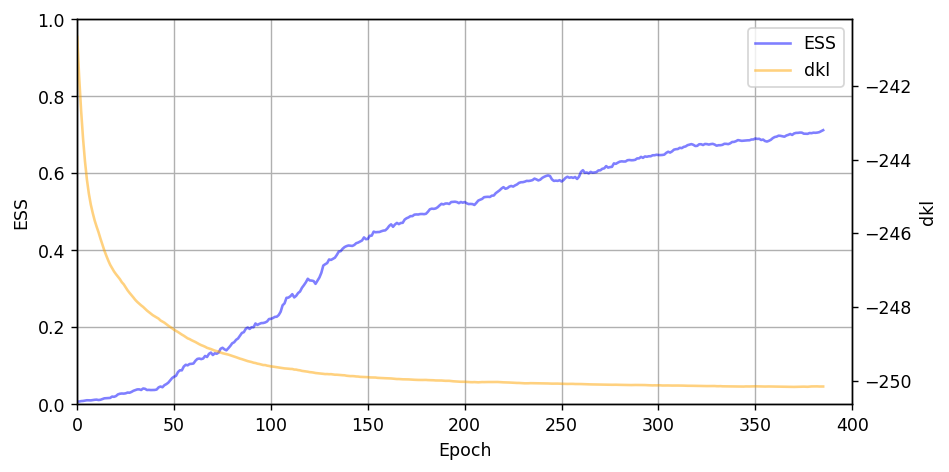

Era   0 epoch    0 ellapsed time 7.0
dkl -229.011
std_dkl 6.52195
loss 0.00659215
ess 0.00126303
Era   1 epoch    0 ellapsed time 585.8
dkl -247.403
std_dkl 2.2696
loss -24.895
ess 0.0764559
Era   2 epoch    0 ellapsed time 1146.4
dkl -249.846
std_dkl 1.0053
loss -27.2942
ess 0.393687
Era   3 epoch    0 ellapsed time 1688.4
dkl -250.073
std_dkl 0.743029
loss -27.8583
ess 0.582075
CPU times: total: 2h 14min 36s
Wall time: 35min 26s


In [55]:
%%time
[plt.close(plt.figure(fignum)) for fignum in plt.get_fignums()] # close all existing figures
live_plot = init_live_plot(N_era, N_epoch, metric='dkl')
start_time = time.time()

for era in range(N_era):
    for epoch in range(N_epoch):
      optimizer.zero_grad()
      loss, log_q, log_p =train_step.step(batch_size=batch_size)
      um.add_metrics(history, {
                "loss": loss.cpu().numpy().item(),
                "ess": neumc.utils.ess(log_p, log_q).cpu().numpy().item(),
                "dkl": neumc.utils.dkl(log_p, log_q).cpu().numpy().item(),
                "std_dkl": (log_p - log_q).std().cpu().numpy().item(),
        })
      optimizer.step()
        
      if epoch % print_freq == 0:
            avg = um.average_metrics(history, N_epoch, history.keys())
            ellapsed_time = time.time()-start_time
            print(f"Era {era:3d} epoch {epoch:4d} ellapsed time {ellapsed_time:.1f}")
            um.print_dict(avg)


      if epoch % plot_freq == 0:
            update_plots(history, **live_plot)


## Sampling

Please refer to the $\phi^4$ notebook for the detailed explanation of concepts and quantities used in the  following.  

The sampling function generates n_samples of configurations from the distribution $q$. The sampling is done in batches because the sample can be to big to fit on the GPU.

In [56]:
%%time
u,lq = neumc.nf.flow.sample(n_samples=2**16, batch_size=2**10, prior=prior, layers=layers)

CPU times: total: 3min 4s
Wall time: 46.9 s


Calculating action, that is equal to $-\log p$, on the sample is also done in batches, for the same reason as above|

In [57]:
lp = -neumc.utils.batch_function.batch_action(u,batch_size=1024, action=u1_action, device=torch_device)

The trained model has a decent effective sample size

In [58]:
ess = neumc.utils.ess(lp,lq)
print(f"ESS = {ess:.3f}")

ESS = 0.712


In [59]:
fit = linregress(lq, lp)
print(f"log P = {fit.slope:.3f} log q + {fit.intercept:.3f}")

log P = 1.013 log q + 252.976


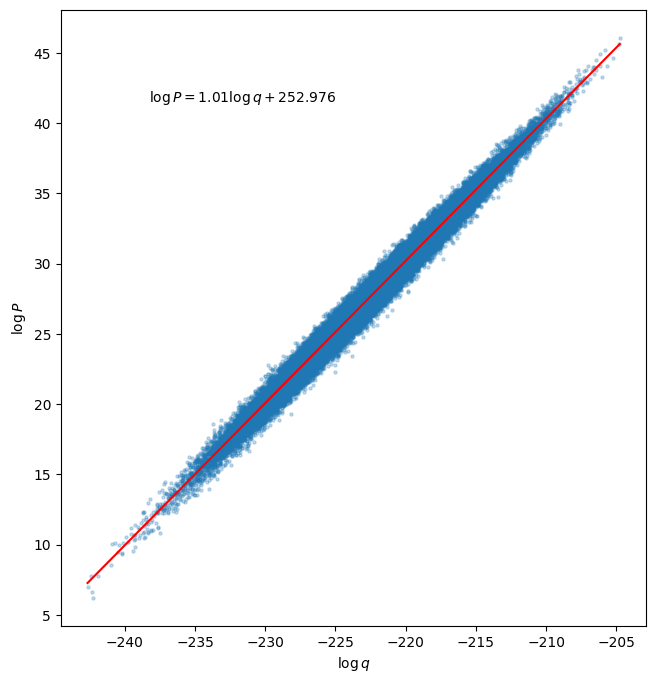

In [60]:
fig, ax = plt.subplots(figsize=(8,8))
ax.set_aspect(1);ax.set_xlabel(r"$\log q$");ax.set_ylabel(r"$\log P$")
lqs = np.linspace(lq.min(), lq.max(),100);
ax.scatter(lq,lp,s=5, alpha=0.25);
ax.plot(lqs, lqs*fit.slope+fit.intercept, color='red',zorder=10);
ax.text(0.15, .85,f"$\\log P = {fit.slope:.3}\\log q+{fit.intercept:.3f}$", transform=ax.transAxes);

## Free energy

As described in the $\phi^4$ notebook the variational free energy is given by the $D_{KL}$

In [61]:
F_q = neumc.utils.dkl(lp,lq)
print(f"F_q = {F_q:.3f} F_q-F_exact = {F_q-F_exact:.4f}")

F_q = -250.171 F_q-F_exact = 0.1754


Please note that the relative error is below $1\perthousand$

In [62]:
print(f"{(F_q-F_exact)/np.abs(F_exact):.5f}")

0.00070


The statistical error can be calculated using the bootstrap

In [63]:
from neumc.utils.stats_utils import torch_bootstrap, torch_bootstrapf

In [64]:
lw = lp-lq

In [65]:
%%time
F_q, F_q_std = torch_bootstrap(-lw, n_samples=100, binsize=1)

CPU times: total: 1.06 s
Wall time: 318 ms


In [66]:
print(f"F_q = {F_q:.4f}+/-{F_q_std:.4f}")

F_q = -250.1718+/-0.0024


The statistical error is much less than the difference indicating that the variational estimate is biased. As explained in the$\phi^4$ notebook we can use the _importance  weights_ 

$$w(u)=\frac{p(u)}{q(u)}$$

to obtain an (almost)unbiased estimate

In [67]:
%%time
F_nis, F_nis_std = torch_bootstrapf(lambda x: -(torch.special.logsumexp(x, 0) - np.log(len(x))), lw,
                                    n_samples=100,
                                    binsize=1)

CPU times: total: 1.03 s
Wall time: 310 ms


In [68]:
print(f"F_NIS = {F_nis:.3f}+/-{F_nis_std:.4f} F_NIS-F_exact = {F_nis-F_exact:.4f}")

F_NIS = -250.345+/-0.0026 F_NIS-F_exact = 0.0018


## Neural Markov Chain Monte-Carlo

In [69]:
from neumc.mc import metropolize

In [70]:
u_p, s_p, s_q, accepted = metropolize(u, lq, lp)

In [71]:
print("Accept rate:", grab(accepted).mean())

Accept rate: 0.6825714


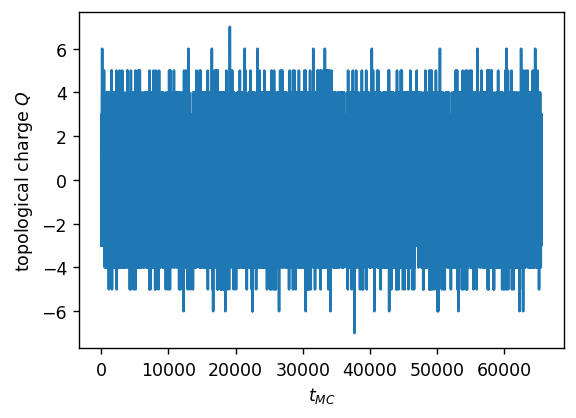

In [72]:
Q = grab(u1.topo_charge(u_p))
plt.figure(figsize=(5,3.5), dpi=125)
plt.plot(Q)
plt.xlabel(r'$t_{MC}$')
plt.ylabel(r'topological charge $Q$')
plt.show()

In [73]:
from neumc.utils.stats_utils import bootstrap

In [74]:
X_mean, X_err = bootstrap(Q**2, n_samples=100, binsize=16)
print(f'Topological susceptibility = {X_mean:.2f} +/- {X_err:.2f}')

Topological susceptibility = 2.59 +/- 0.02


## Rational splines coupling with different masking patterns

In [75]:
from mask_plots import plot_plaq_mask, loop

In [76]:
masks_gen = neumc.nf.gauge_masks.sch_masks_gen(lattice_shape=(L, L), float_dtype=float_dtype, device='cpu')
masks = [next(masks_gen) for i in range(8)]

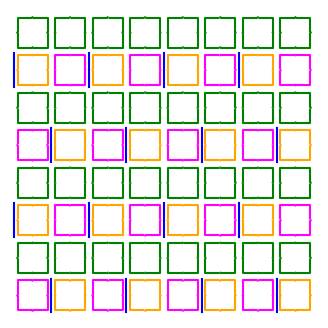

In [77]:
fig, ax = plt.subplots(figsize=(4,4))
ax.set_aspect(1)
plot_plaq_mask(ax, masks[6]);

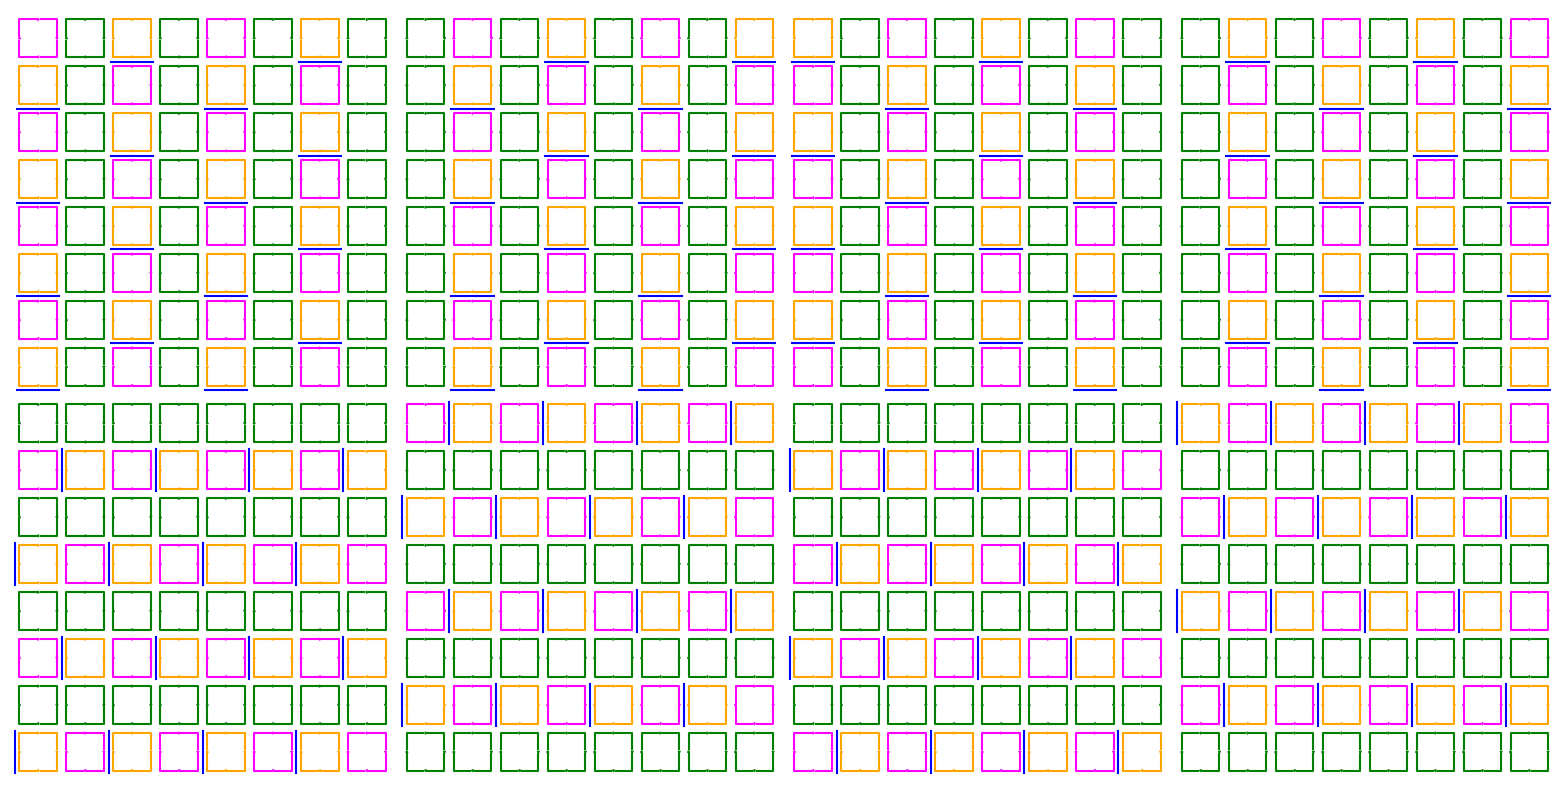

In [78]:
fig, ax = plt.subplots(2,4,figsize=(20,10))
plt.subplots_adjust(hspace=0, wspace=0)
axs = ax.ravel()
for i in range(8):
    plot_plaq_mask(axs[i], masks[i]);

In [79]:
masks = neumc.nf.gauge_masks.sch_masks_gen(lattice_shape=(L, L),
                                           float_dtype=float_dtype, device=torch_device)

In [80]:
def make_plaq_coupling(mask):
    out_channels = 3 * (n_knots - 1) + 1
    net = neumc.nf.nn.make_conv_net(in_channels=in_channels,
                        out_channels=out_channels,
                        hidden_channels=hidden_channels,
                        kernel_size=kernel_size,
                        use_final_tanh=False,
                        dilation=dilation)
    net.to(torch_device)
    return cs_cpl.CSCoupling(n_knots=n_knots, net=net, mask=mask)

In [81]:
n_layers = 16
layers = neumc.nf.u1_equiv.make_u1_equiv_layers(loops_function=None,
                                                make_plaq_coupling=make_plaq_coupling,
                                                masks=masks, n_layers=n_layers, device=torch_device)

In [82]:
model={
  'prior':prior,
  'layers': layers
}

In [83]:
N_era = 4
N_epoch = 100
print_freq = 100 # epochs
plot_freq = 1 # epochs

history = {
    'dkl' : [],
    'std_dkl': [],
    'loss' : [],
    'ess' : []
}

In [84]:
# Training
base_lr = .001
optimizer = torch.optim.Adam(model['layers'].parameters(), lr=base_lr)
#optimizer = to

In [85]:
train_step2 = PathGradientEstimator(prior=prior, flow = layers, action=u1_action)

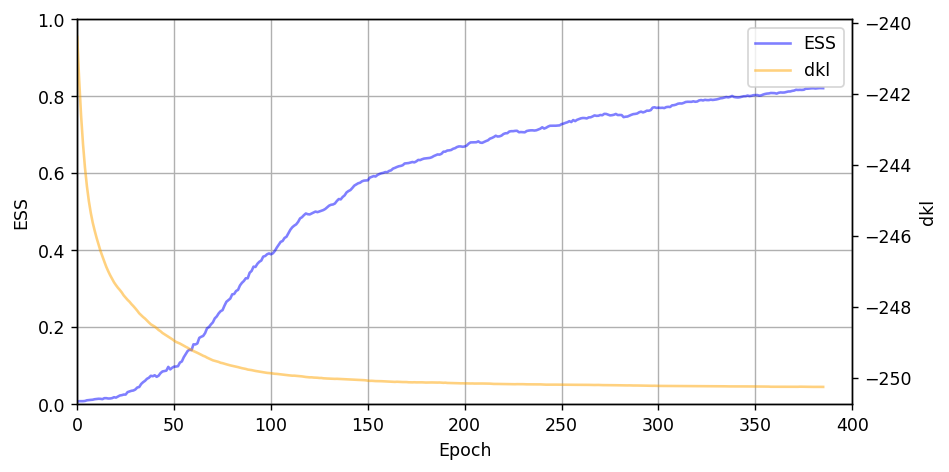

Era   0 epoch    0 ellapsed time 4.4
dkl -227.518
std_dkl 7.0239
loss 0.768483
ess 0.00160116
Era   1 epoch    0 ellapsed time 443.0
dkl -247.63
std_dkl 2.13356
loss -25.5044
ess 0.119302
Era   2 epoch    0 ellapsed time 905.1
dkl -250.028
std_dkl 0.791714
loss -28.0192
ess 0.547849
Era   3 epoch    0 ellapsed time 1281.0
dkl -250.178
std_dkl 0.576397
loss -28.2884
ess 0.719839
CPU times: total: 1h 45min 17s
Wall time: 27min 6s


In [86]:
%%time
[plt.close(plt.figure(fignum)) for fignum in plt.get_fignums()] # close all existing figures
live_plot = init_live_plot(N_era, N_epoch, metric='dkl')
start_time = time.time()

for era in range(N_era):
    for epoch in range(N_epoch):
        optimizer.zero_grad()  
        loss, log_q, log_p = train_step2.step(batch_size=batch_size)
        optimizer.step()
        um.add_metrics(history, {
                "loss": loss.cpu().numpy().item(),
                "ess": neumc.utils.ess(log_p, log_q).cpu().numpy().item(),
                "dkl": neumc.utils.dkl(log_p, log_q).cpu().numpy().item(),
                "std_dkl": (log_p - log_q).std().cpu().numpy().item(),
        })
        
        if epoch % print_freq == 0:
            avg = um.average_metrics(history, N_epoch, history.keys())
            ellapsed_time = time.time()-start_time
            print(f"Era {era:3d} epoch {epoch:4d} ellapsed time {ellapsed_time:.1f}")
            um.print_dict(avg)

        if epoch % plot_freq == 0:
            update_plots(history, **live_plot)

### Sampling

In [87]:
%%time
u_sch, lq_sch = neumc.nf.flow.sample(n_samples=2**16, batch_size=2**10, prior=prior, layers=layers)

CPU times: total: 2min 27s
Wall time: 37.6 s


In [88]:
lp_sch = -neumc.utils.batch_function.batch_action(u_sch,batch_size=1024, action=u1_action, device=torch_device)

In [89]:
ess_sch = neumc.utils.ess(lp_sch,lq_sch)
print(f"ESS = {ess_sch:.3f}  change {100*(ess_sch-ess)/ess:.1f}%")

ESS = 0.826  change 16.0%


## Free energy

In [90]:
lw_sch = lp_sch-lq_sch

In [91]:
%%time
F_q_sch, F_q_std_sch = torch_bootstrap(-lw_sch, n_samples=100, binsize=1)

CPU times: total: 1 s
Wall time: 246 ms


In [92]:
print(f"F_q = {F_q_sch:.4f}+/-{F_q_std_sch:.4f}  F_q-F_exact = {F_q_sch - F_exact:.5f}")

F_q = -250.2494+/-0.0018  F_q-F_exact = 0.09741


In [93]:
%%time
F_nis_sch, F_nis_std_sch = torch_bootstrapf(lambda x: -(torch.special.logsumexp(x, 0) - np.log(len(x))), 
                                    lw_sch, n_samples=100, binsize=1)

CPU times: total: 1 s
Wall time: 248 ms


In [94]:
print(f"F_NIS = {F_nis_sch:.3f}+/-{F_nis_std_sch:.4f} F_NIS-F_exact = {F_nis_sch-F_exact:.4f}")

F_NIS = -250.346+/-0.0017 F_NIS-F_exact = 0.0008


## Rational splines coupling with $2\times 1$ loops

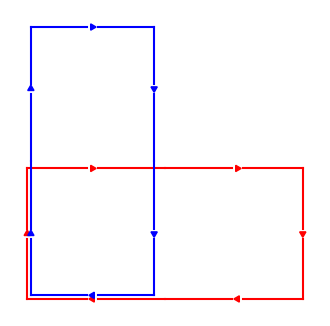

In [95]:
from mask_plots import loop, plot_plaq_mask
fig, ax = plt.subplots(figsize=(4,4))
ax.set_aspect(1.0)
#
ax.axis('off')
loop(ax,0,0,'urrdll',l=0.035, d=0.05, color='red')
loop(ax,0,0,'uurddl', l=0.035, d= 0.075, color='blue')

In [96]:
masks = neumc.nf.gauge_masks.sch_2x1_masks_gen(lattice_shape=(8, 8),
                                               float_dtype=float_dtype, device=torch_device)

In [97]:
mask0 =next(masks)

In [98]:
mask0[1][0]

{'frozen': tensor([[0., 0., 0., 0., 0., 0., 0., 0.],
         [1., 1., 1., 1., 1., 1., 1., 1.],
         [0., 0., 0., 0., 0., 0., 0., 0.],
         [1., 1., 1., 1., 1., 1., 1., 1.],
         [0., 0., 0., 0., 0., 0., 0., 0.],
         [1., 1., 1., 1., 1., 1., 1., 1.],
         [0., 0., 0., 0., 0., 0., 0., 0.],
         [1., 1., 1., 1., 1., 1., 1., 1.]]),
 'active': tensor([[1., 0., 1., 0., 1., 0., 1., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 1., 0., 1., 0., 1., 0., 1.],
         [0., 0., 0., 0., 0., 0., 0., 0.],
         [1., 0., 1., 0., 1., 0., 1., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 1., 0., 1., 0., 1., 0., 1.],
         [0., 0., 0., 0., 0., 0., 0., 0.]]),
 'passive': tensor([[0., 1., 0., 1., 0., 1., 0., 1.],
         [0., 0., 0., 0., 0., 0., 0., 0.],
         [1., 0., 1., 0., 1., 0., 1., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 1., 0., 1., 0., 1., 0., 1.],
         [0., 0., 0., 0., 0., 0., 0., 0.],
         [1., 0., 1

In [99]:
mask0[1][1]

{'frozen': tensor([[[0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0., 0.]],
 
         [[0., 0., 0., 0., 0., 0., 0., 0.],
          [1., 1., 1., 1., 1., 1., 1., 1.],
          [0., 0., 0., 0., 0., 0., 0., 0.],
          [1., 1., 1., 1., 1., 1., 1., 1.],
          [0., 0., 0., 0., 0., 0., 0., 0.],
          [1., 1., 1., 1., 1., 1., 1., 1.],
          [0., 0., 0., 0., 0., 0., 0., 0.],
          [1., 1., 1., 1., 1., 1., 1., 1.]]])}

In [100]:
masks = neumc.nf.gauge_masks.sch_2x1_masks_gen(lattice_shape=(L, L),
                                               float_dtype=float_dtype, device=torch_device)

In [101]:
in_channels = 6

In [102]:
def make_plaq_coupling(mask):
    out_channels = 3 * (n_knots - 1) + 1
    net = neumc.nf.nn.make_conv_net(in_channels=in_channels,
                        out_channels=out_channels,
                        hidden_channels=hidden_channels,
                        kernel_size=kernel_size,
                        use_final_tanh=False,
                        dilation=dilation)
    net.to(torch_device)
    return cs_cpl.CSCoupling(n_knots=n_knots, net=net, mask=mask)

In [103]:
n_layers = 16
loops_function = lambda x: [u1.compute_u1_2x1_loops(x)]
layers = neumc.nf.u1_equiv.make_u1_equiv_layers(loops_function=loops_function,
                                                make_plaq_coupling=make_plaq_coupling,
                                                masks=masks, n_layers=n_layers, device=torch_device)

In [104]:
model={
  'prior':prior,
  'layers': layers
}

In [105]:
N_era = 4
N_epoch = 100
print_freq = 100 # epochs
plot_freq = 1 # epochs

history = {
    'dkl' : [],
    'std_dkl': [],
    'loss' : [],
    'ess' : []
}

In [106]:
# Training
base_lr = .001
optimizer = torch.optim.Adam(model['layers'].parameters(), lr=base_lr)
#optimizer = to

In [107]:
train_step3 = PathGradientEstimator(prior,layers, u1_action)

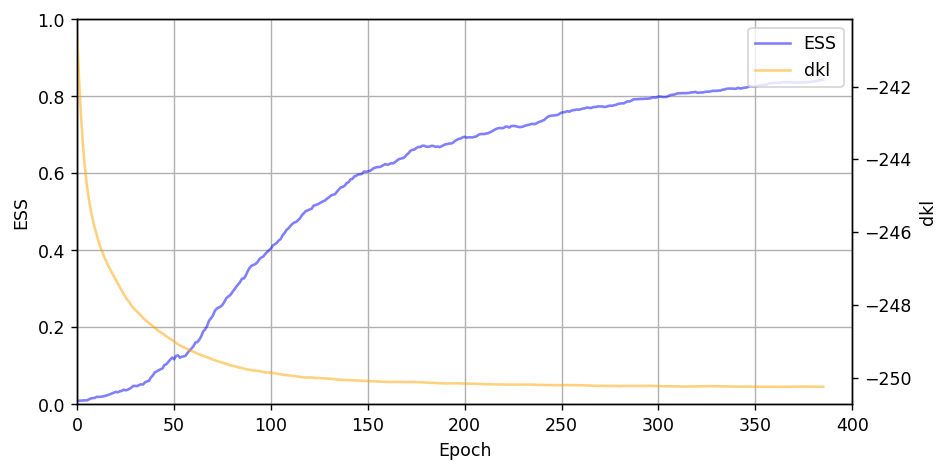

Era   0 epoch    0 ellapsed time 4.1
dkl -227.541
std_dkl 7.04788
loss -2.73131
ess 0.00187469
Era   1 epoch    0 ellapsed time 383.5
dkl -247.694
std_dkl 2.09774
loss -25.6303
ess 0.126473
Era   2 epoch    0 ellapsed time 766.9
dkl -250.048
std_dkl 0.771106
loss -27.8956
ess 0.567176
Era   3 epoch    0 ellapsed time 1171.6
dkl -250.201
std_dkl 0.547525
loss -28.3737
ess 0.743196
CPU times: total: 1h 41min 24s
Wall time: 25min 54s


In [108]:
%%time
[plt.close(plt.figure(fignum)) for fignum in plt.get_fignums()] # close all existing figures
live_plot = init_live_plot(N_era, N_epoch, metric='dkl')
start_time = time.time()

for era in range(N_era):
    for epoch in range(N_epoch):
        optimizer.zero_grad()
        loss, log_q, log_p = train_step3.step(batch_size=batch_size)
        optimizer.step()
      
        um.add_metrics(history, {
                "loss": loss.cpu().numpy().item(),
                "ess": neumc.utils.ess(log_p, log_q).cpu().numpy().item(),
                "dkl": neumc.utils.dkl(log_p, log_q).cpu().numpy().item(),
                "std_dkl": (log_p - log_q).std().cpu().numpy().item(),
        })
        
        if epoch % print_freq == 0:
            avg = um.average_metrics(history, N_epoch, history.keys())
            ellapsed_time = time.time()-start_time
            print(f"Era {era:3d} epoch {epoch:4d} ellapsed time {ellapsed_time:.1f}")
            um.print_dict(avg)

        if epoch % plot_freq == 0:
            update_plots(history, **live_plot)

### Sampling

In [109]:
%%time
u_2x1, lq_2x1 = neumc.nf.flow.sample(n_samples=2**16, batch_size=2**10, prior=prior, layers=layers)

CPU times: total: 2min 18s
Wall time: 35 s


In [110]:
lp_2x1 = -neumc.utils.batch_function.batch_action(u_2x1,batch_size=1024, action=u1_action, 
                                           device=torch_device)

In [111]:
ess_2x1 = neumc.utils.ess_lw((lq_2x1-lp_2x1))
print(f"ESS = {ess_2x1:.3f}  change {100*(ess_2x1-ess_sch)/ess_sch:.1f}%")

ESS = 0.846  change 2.4%


## Free energy

In [112]:
lw_2x1 = lp_2x1-lq_2x1

In [113]:
%%time
F_q_2x1, F_q_std_2x1 = torch_bootstrap(-lw_2x1, n_samples=100, binsize=1)

CPU times: total: 906 ms
Wall time: 223 ms


In [114]:
print(f"F_q = {F_q_2x1:.4f}+/-{F_q_std_2x1:.4f}  F_q-F_exact = {F_q_2x1 - F_exact:.5f}")

F_q = -250.2620+/-0.0014  F_q-F_exact = 0.08478


In [115]:
%%time
F_nis_2x1, F_nis_std_2x1 = torch_bootstrapf(
  lambda x: -(torch.special.logsumexp(x, 0) - np.log(len(x))), 
                                    lw_2x1, n_samples=100, binsize=1)

CPU times: total: 938 ms
Wall time: 231 ms


In [116]:
print(f"F_NIS = {F_nis_2x1:.3f}+/-{F_nis_std_2x1:.4f} F_NIS-F_exact = {F_nis_2x1-F_exact:.4f}")

F_NIS = -250.346+/-0.0019 F_NIS-F_exact = 0.0006
